# 📦 Parte 1 — Conversão para TensorFlow Lite Micro
> **TinyML · Arduino Nano 33 BLE Sense**
>
> Converte o modelo Keras treinado no notebook anterior para um arquivo `.tflite` quantizado em **int8**,
> e em seguida gera um array C (`model_data.h`) pronto para ser compilado no Arduino.

## Pipeline deste notebook
```
SavedModel / .h5
      ↓
  TFLiteConverter  →  float32 .tflite  (baseline)
      ↓
  Quantização int8  →  quantized .tflite  (embarcado)
      ↓
  xxd / Python      →  model_data.h  (array C)
      ↓
  Validação de inferência  →  teste de sanidade
```

## 1. Dependências

In [1]:
import os, sys, struct
import numpy as np
import tensorflow as tf

print(f'TensorFlow {tf.__version__}')

OUTPUTS = '../outputs'
ARDUINO = '../arduino/inferencia_gestos'
os.makedirs(OUTPUTS, exist_ok=True)
os.makedirs(ARDUINO, exist_ok=True)

I0000 00:00:1778259631.002206   24746 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778259631.056556   24746 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778259632.305774   24746 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow 2.21.0


## 2. Carregar modelo e dados de calibração

In [2]:
# Carrega modelo salvo no notebook 01
model = tf.keras.models.load_model(f'{OUTPUTS}/gesture_model.h5')
model.summary()

# Parâmetros de normalização salvos no notebook 01
norm_mean = np.load(f'{OUTPUTS}/norm_mean.npy')
norm_std  = np.load(f'{OUTPUTS}/norm_std.npy')
print(f'\nmédia normalização: {norm_mean}')
print(f'std   normalização: {norm_std}')

E0000 00:00:1778259642.808430   24746 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "gesture_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 714)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │        45,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,805 (190.65 KB)

 Trainable params: 48,611 (189.89 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 2 (12.00 B)


média normalização: [ 0.07509518 -0.17964466 -0.21709919  2.6279018  -0.09379248  2.9360886 ]
std   normalização: [ 0.43974835  0.33774292  0.90554374 26.584227   31.20078    35.28196   ]


## 3. Conjunto de representação (calibração para quantização)

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

NUM_SAMPLES  = 119
NUM_FEATURES = 6
NUM_CLASSES  = 3
CLASSES      = ['punch', 'flex', 'idle']

# Recria dados sintéticos para calibração (substitua por dados reais)
def generate_synthetic(n=40, noise=0.15, pattern='punch'):
    data = []
    for _ in range(n):
        t = np.linspace(0, 1, NUM_SAMPLES)
        if pattern == 'punch':
            sig = np.stack([
                np.exp(-((t-0.3)/0.1)**2) + np.random.normal(0, noise, NUM_SAMPLES),
                *[np.random.normal(0, noise, NUM_SAMPLES) for _ in range(5)]
            ], axis=1)
        elif pattern == 'flex':
            sig = np.stack([
                np.random.normal(0, noise, NUM_SAMPLES),
                np.sin(2 * np.pi * 2 * t) + np.random.normal(0, noise, NUM_SAMPLES),
                *[np.random.normal(0, noise, NUM_SAMPLES) for _ in range(4)]
            ], axis=1)
        else:
            sig = np.random.normal(0, noise / 3, (NUM_SAMPLES, NUM_FEATURES))
        data.append(sig.astype(np.float32))
    return np.array(data)

X_cal = np.concatenate([generate_synthetic(40, pattern=c) for c in CLASSES], axis=0)
X_cal = ((X_cal.reshape(-1, NUM_FEATURES) - norm_mean) / norm_std
         ).reshape(len(X_cal), -1).astype(np.float32)

print(f'Conjunto de calibração: {X_cal.shape}')

Conjunto de calibração: (120, 714)


## 4. Conversão float32 (baseline)

In [4]:
converter_f32 = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_f32    = converter_f32.convert()

path_f32 = f'{OUTPUTS}/gesture_float32.tflite'
with open(path_f32, 'wb') as f:
    f.write(tflite_f32)

size_kb = os.path.getsize(path_f32) / 1024
print(f'✓ float32 .tflite salvo: {size_kb:.1f} KB  →  {path_f32}')

INFO:tensorflow:Assets written to: /tmp/tmpgo7xkncx/assets


INFO:tensorflow:Assets written to: /tmp/tmpgo7xkncx/assets


Saved artifact at '/tmp/tmpgo7xkncx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 714), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  129422482330496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482335424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482459104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482459808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482340000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482457168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482337536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482461216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482462976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482460688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482460336: TensorSpec(s

W0000 00:00:1778259663.554931   24746 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1778259663.555006   24746 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1778259663.555844   24746 reader.cc:83] Reading SavedModel from: /tmp/tmpgo7xkncx
I0000 00:00:1778259663.557195   24746 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1778259663.557255   24746 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpgo7xkncx
I0000 00:00:1778259663.567031   24746 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1778259663.568596   24746 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1778259663.606980   24746 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpgo7xkncx
I0000 00:00:1778259663.618468   24746 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 62636 microseconds.
I0000 00:00:1778259663.631445   24746

## 5. Quantização int8 (modo full-integer)

A quantização **full-integer** faz com que:
- Todos os pesos fiquem em `int8` (4× menor que float32)
- As ativações também fiquem em `int8` (MCUs sem FPU rodam muito mais rápido)
- O tensor de entrada/saída fique em `int8` (exige dequantização no Arduino)

In [5]:
def representative_dataset():
    """Gera amostras float32 para o TFLite Converter calibrar os ranges int8."""
    for i in range(len(X_cal)):
        yield [X_cal[i:i+1]]  # shape (1, 714)


converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)

# Ativa quantização full-integer
converter_int8.optimizations         = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type  = tf.int8
converter_int8.inference_output_type = tf.int8

tflite_int8 = converter_int8.convert()

path_int8 = f'{OUTPUTS}/gesture_int8.tflite'
with open(path_int8, 'wb') as f:
    f.write(tflite_int8)

size_int8 = os.path.getsize(path_int8) / 1024
print(f'✓ int8 .tflite salvo: {size_int8:.1f} KB  →  {path_int8}')
print(f'  Redução: {size_kb/size_int8:.1f}× menor que float32')

INFO:tensorflow:Assets written to: /tmp/tmp_tgpg__j/assets


INFO:tensorflow:Assets written to: /tmp/tmp_tgpg__j/assets


Saved artifact at '/tmp/tmp_tgpg__j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 714), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  129422482330496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482335424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482459104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482459808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482340000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482457168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482337536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482461216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482462976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482460688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129422482460336: TensorSpec(s

/home/usuario/Documentos/tinyml/env/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✓ int8 .tflite salvo: 54.0 KB  →  ../outputs/gesture_int8.tflite
  Redução: 3.6× menor que float32


W0000 00:00:1778259674.253957   24746 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1778259674.253977   24746 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1778259674.254125   24746 reader.cc:83] Reading SavedModel from: /tmp/tmp_tgpg__j
I0000 00:00:1778259674.254728   24746 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1778259674.254736   24746 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp_tgpg__j
I0000 00:00:1778259674.260408   24746 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1778259674.297534   24746 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp_tgpg__j
I0000 00:00:1778259674.309188   24746 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 55073 microseconds.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1778259674.398813   24746 flatbuffer_export.cc:

## 6. Validação da inferência TFLite

In [6]:
def run_tflite(model_path, sample_f32):
    """Executa uma amostra no intérprete TFLite e retorna probabilidades."""
    interp = tf.lite.Interpreter(model_path=model_path)
    interp.allocate_tensors()
    inp_det = interp.get_input_details()[0]
    out_det = interp.get_output_details()[0]

    # Quantiza entrada se necessário
    if inp_det['dtype'] == np.int8:
        scale, zp = inp_det['quantization']
        inp_data = (sample_f32 / scale + zp).astype(np.int8)
    else:
        inp_data = sample_f32.astype(np.float32)

    interp.set_tensor(inp_det['index'], inp_data)
    interp.invoke()
    raw = interp.get_tensor(out_det['index'])

    # Dequantiza saída se necessário
    if out_det['dtype'] == np.int8:
        scale, zp = out_det['quantization']
        return (raw.astype(np.float32) - zp) * scale
    return raw


# Teste com 5 amostras aleatórias
print(f'{"Idx":>4} {"Real":>8} {"Keras":>12} {"TFLite f32":>12} {"TFLite int8":>12}')
print('-' * 54)
indices = np.random.choice(len(X_cal), 5, replace=False)
for i in indices:
    s = X_cal[i:i+1]
    cls_real  = CLASSES[int(np.floor(i / (len(X_cal)//3)))]
    out_keras = model.predict(s, verbose=0)
    out_f32   = run_tflite(path_f32,  s)
    out_int8  = run_tflite(path_int8, s)
    print(f'{i:>4} {cls_real:>8} {CLASSES[np.argmax(out_keras)]:>12} '
          f'{CLASSES[np.argmax(out_f32)]:>12} {CLASSES[np.argmax(out_int8)]:>12}')

 Idx     Real        Keras   TFLite f32  TFLite int8
------------------------------------------------------
  90     idle         idle         idle         idle
  41     flex         idle         idle         idle


/home/usuario/Documentos/tinyml/env/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


 104     idle         idle         idle         idle
  84     idle         idle         idle         idle
  55     flex         idle         idle         idle


## 7. Análise de tamanho dos modelos

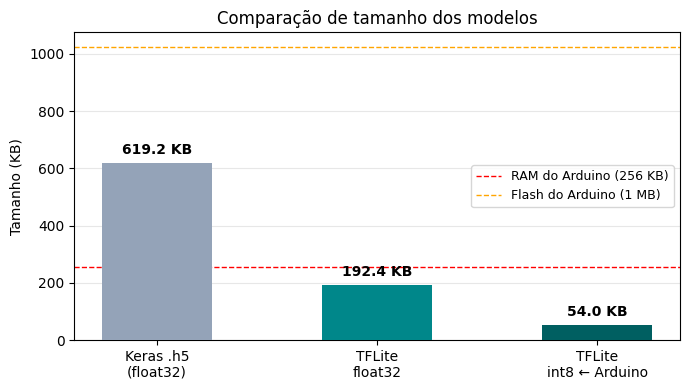

In [7]:
import matplotlib.pyplot as plt

h5_size   = os.path.getsize(f'{OUTPUTS}/gesture_model.h5') / 1024
f32_size  = os.path.getsize(path_f32)  / 1024
int8_size = os.path.getsize(path_int8) / 1024

labels = ['Keras .h5\n(float32)', 'TFLite\nfloat32', 'TFLite\nint8 ← Arduino']
sizes  = [h5_size, f32_size, int8_size]
colors = ['#94a3b8', '#00878a', '#005f61']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, sizes, color=colors, width=0.5, zorder=3)
ax.bar_label(bars, fmt='%.1f KB', padding=4, fontweight='bold')
ax.axhline(256, color='red', linestyle='--', linewidth=1, label='RAM do Arduino (256 KB)')
ax.axhline(1024, color='orange', linestyle='--', linewidth=1, label='Flash do Arduino (1 MB)')
ax.set_ylabel('Tamanho (KB)')
ax.set_title('Comparação de tamanho dos modelos')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3, zorder=0)
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/tamanho_modelos.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Gerar `model_data.h` — array C para o Arduino

O TensorFlow Lite Micro exige que o modelo seja um array de bytes em C.
O equivalente ao comando `xxd -i gesture_int8.tflite > model_data.h`.

In [8]:
def tflite_to_c_array(tflite_bytes, var_name='g_model_data'):
    """Converte bytes .tflite em string de array C compatível com TFLM."""
    lines = []
    lines.append(f'// Gerado automaticamente por 02_conversao_tflite.ipynb')
    lines.append(f'// Modelo: gesture_int8.tflite  |  {len(tflite_bytes)} bytes')
    lines.append(f'')
    lines.append(f'#pragma once')
    lines.append(f'#include <stdint.h>')
    lines.append(f'')
    lines.append(f'alignas(8) const uint8_t {var_name}[] = {{')

    # 12 bytes por linha
    for i in range(0, len(tflite_bytes), 12):
        chunk = tflite_bytes[i:i+12]
        hex_str = ', '.join(f'0x{b:02x}' for b in chunk)
        lines.append(f'  {hex_str},')

    lines.append(f'}};')
    lines.append(f'const unsigned int {var_name}_len = {len(tflite_bytes)};')
    return '\n'.join(lines)


c_code = tflite_to_c_array(tflite_int8)

# Salva no diretório do sketch Arduino
header_path = f'{ARDUINO}/model_data.h'
with open(header_path, 'w') as f:
    f.write(c_code)

print(f'✓ model_data.h salvo em {header_path}')
print(f'  Linhas: {c_code.count(chr(10))}')
print(f'  Tamanho final: {len(tflite_int8)} bytes')

✓ model_data.h salvo em ../arduino/inferencia_gestos/model_data.h
  Linhas: 4615
  Tamanho final: 55280 bytes


## 9. Gerar `norm_params.h` — parâmetros de normalização para o Arduino

In [9]:
def array_to_c(arr, name, dtype='float'):
    vals = ', '.join(f'{v:.8f}f' for v in arr)
    return f'const {dtype} {name}[{len(arr)}] = {{{vals}}};\n'


norm_header = '// Parâmetros de normalização (mean/std por feature)\n'
norm_header += '// Gerado por 02_conversao_tflite.ipynb\n\n'
norm_header += '#pragma once\n\n'
norm_header += array_to_c(norm_mean, 'kNormMean')
norm_header += array_to_c(norm_std,  'kNormStd')
norm_header += f'\nconst int kNumSamples  = {119};\n'
norm_header += f'const int kNumFeatures = {6};\n'
norm_header += f'const int kNumClasses  = {3};\n'
norm_header += '\nconst char* kClassLabels[] = {"punch", "flex", "idle"};\n'

norm_path = f'{ARDUINO}/norm_params.h'
with open(norm_path, 'w') as f:
    f.write(norm_header)

print('✓ norm_params.h salvo em', norm_path)
print()
print(norm_header)

✓ norm_params.h salvo em ../arduino/inferencia_gestos/norm_params.h

// Parâmetros de normalização (mean/std por feature)
// Gerado por 02_conversao_tflite.ipynb

#pragma once

const float kNormMean[6] = {0.07509518f, -0.17964466f, -0.21709919f, 2.62790179f, -0.09379248f, 2.93608856f};
const float kNormStd[6] = {0.43974835f, 0.33774292f, 0.90554374f, 26.58422661f, 31.20078087f, 35.28195953f};

const int kNumSamples  = 119;
const int kNumFeatures = 6;
const int kNumClasses  = 3;

const char* kClassLabels[] = {"punch", "flex", "idle"};



## 10. Resumo e próximos passos

In [ ]:
print('  RESUMO DA CONVERSÃO')
print(f'  gesture_model.h5          {h5_size:6.1f} KB  (Keras)')
print(f'  gesture_float32.tflite    {f32_size:6.1f} KB  (TFLite baseline)')
print(f'  gesture_int8.tflite       {int8_size:6.1f} KB  (quantizado int8)')
print(f'  model_data.h              → embedado no Arduino')
print(f'  norm_params.h             → normalização no Arduino')
print()
print('Próximos passos:')
print('   1. Compile inferencia_gestos.ino na Arduino IDE')
print('   2. Faça upload para o Arduino Nano 33 BLE Sense')
print('   3. Abra o Monitor Serial (115200 baud)')
print('   4. Realize gestos e veja a classificação em tempo real!')

  RESUMO DA CONVERSÃO
  gesture_model.h5           619.2 KB  (Keras)
  gesture_float32.tflite     192.4 KB  (TFLite baseline)
  gesture_int8.tflite         54.0 KB  (quantizado int8)
  model_data.h              → embedado no Arduino
  norm_params.h             → normalização no Arduino

✅ Próximos passos:
   1. Compile inferencia_gestos.ino na Arduino IDE
   2. Faça upload para o Arduino Nano 33 BLE Sense
   3. Abra o Monitor Serial (115200 baud)
   4. Realize gestos e veja a classificação em tempo real!
